# ระบบคัดกรองคำขอสินเชื่อ: ต้นแบบ Pipeline ทั้งระบบ (Prototype Notebook)

**รายวิชา CP413008 Machine Learning Engineering for Production · โครงงานปลายภาค**

ชุดข้อมูล: [Loan Approval Dataset 2026 (Kaggle)](https://www.kaggle.com/datasets/mmumairkhattak/loan-approval-dataset-2026-credit-risk-and-bank-a) มี 30,000 คำขอ, 36 คอลัมน์, license MIT

### Notebook นี้มีไว้ทำอะไร
ก่อนจะแยกโค้ดไปเป็นสคริปต์, Airflow DAG, Flask API และ CI เราลองเดิน **pipeline ทั้งเส้นให้จบใน notebook เดียวก่อน** เพื่อให้ทั้งกลุ่ม
1. เห็นภาพว่าข้อมูลไหลผ่านขั้นไหนบ้าง และแต่ละขั้นส่งอะไรต่อให้ขั้นถัดไป
2. ได้ตัวเลขจริงไปใช้ตั้งเกณฑ์ (gating metric, SLO, เกณฑ์ drift) แทนการเดา
3. ตัดสินใจเรื่องสำคัญพร้อมหลักฐาน เช่น จะตัดคอลัมน์ไหนทิ้ง และจะใช้โมเดลตัวไหน

### เส้นทางของ pipeline (ตั้งชื่อขั้นตามคอมโพเนนต์ของ TFX ใน Lecture 11 / Lab 11)
```
ข้อมูลดิบ (CSV)
   │
   ▼
[1] ExampleGen ──► [2] StatisticsGen ──► [3] SchemaGen ──► [4] ExampleValidator ──(ข้อมูลเสีย)──► หยุด + แจ้งเตือน
                                                                   │ (ผ่าน)
                                                                   ▼
[5] Transform + Trainer (ทดลองหลายโมเดล, บันทึกใน MLflow) ──► [6] Evaluator (ด่านตรวจ/gate)
                                                                   │ (ผ่าน)
                                                                   ▼
[7] Model Registry (alias champion / ย้อนกลับได้) ──► [8] Serving (ทำนาย + วัด latency)
                                                                   │
                                                                   ▼
[9] Monitoring (data drift / concept drift) ──(เกินเกณฑ์)──► [10] Retrain ──► กลับไปที่ [6]
```

### เครื่องมือที่ใช้ใน notebook นี้ และเคยเจอใน Lab ไหน
| เครื่องมือ | ใช้ทำอะไร | เคยใช้ที่ |
|---|---|---|
| pandas, scikit-learn (`Pipeline`, `ColumnTransformer`, `OneHotEncoder`, `StandardScaler`) | เตรียมข้อมูล + โมเดล | Lab 6, 7, 10, 11 |
| `LogisticRegression`, `RandomForestClassifier`, `HistGradientBoostingClassifier` | โมเดลที่นำมาเทียบกัน | Lab 6, 9, 11 |
| `SimpleImputer` | เติมค่าว่าง | *ใหม่ แต่ง่าย:* แค่แทนค่าว่างด้วย median หรือค่าที่พบบ่อยสุด |
| schema.json + ฟังก์ชันตรวจเอง | Data validation | Lab 11 (`schema_gen`, `example_validator`) |
| MLflow (tracking + registry + alias) | บันทึกการทดลอง, ทะเบียนโมเดล | Lab 9 |
| `permutation_importance` | อธิบายว่าโมเดลดูฟีเจอร์ไหน | Lab 6, Lecture 6 |
| `scipy.stats.ks_2samp`, `chisquare` | ตรวจ data drift | Lab 11 (`monitoring.py`), Lecture 10 |
| `time.perf_counter` + percentile | วัด latency p50/p95 | Lab 7, 10, 12 |
| joblib, md5 | บันทึกโมเดล, ทำ version ของข้อมูล | Lab 5, 7, 11 |

> เมื่อย้ายไปทำระบบจริง ขั้นที่ [1]–[7] จะกลายเป็น task ใน **Airflow DAG** (Lab 11), ขั้น [8] คือ **Flask ใน Docker** (Lab 3, 7) และขั้น [9] ใช้ **Evidently + Prometheus/Grafana** (Lab 10)

## 0. ตั้งค่า (Setup)

**เกณฑ์และค่าคงที่ทุกตัวประกาศไว้ที่เดียวในเซลล์นี้** (หลักเดียวกับ `common.py` ใน Lab 10)
เวลาย้ายไปเป็นระบบจริง ค่าเหล่านี้จะไปอยู่ใน `config.py` ให้ DAG, API และ CI อ่านจากที่เดียวกัน

โค้ดการแปลงข้อมูลกับการตรวจ schema **ไม่ได้เขียนใน notebook** แต่ import มาจากโฟลเดอร์ `src/`
เพราะ API ตอนให้บริการต้องใช้โค้ดชุดเดียวกันเป๊ะ (รายละเอียดอยู่ในหัวข้อ 5)

In [1]:
import logging
import os
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"      # ปิดข้อความแนะนำของ MLflow ที่ไม่เกี่ยวกับงานเรา
import hashlib
import json
import platform
import subprocess
import sys
import time
import warnings
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow import MlflowClient
from scipy import stats
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, recall_score,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)  # แสดงเฉพาะ error ของ MLflow ให้ output อ่านง่าย
pd.set_option("display.max_columns", 50)
plt.rcParams["font.family"] = "Tahoma"          # ฟอนต์ที่มีภาษาไทย (Windows) ให้ชื่อกราฟอ่านออก

# notebook อยู่ในโฟลเดอร์ notebooks/ → ราก project อยู่ขึ้นไปหนึ่งชั้น
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import features as F                       # การแปลงข้อมูล (ใช้ร่วมกับ API)
from src import validation as V                     # schema + การตรวจข้อมูล (ใช้ร่วมกับ API)

RAW_CSV   = ROOT / "data" / "raw" / "loan_approval_dataset.csv"
ARTIFACTS = ROOT / "artifacts" / "notebook"         # ไฟล์ที่ notebook สร้าง (split, schema, รูป)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

SEED = 42                                           # ทุกการสุ่มใช้ค่านี้ → รันซ้ำได้ผลเดิม

# ---- เกณฑ์ด่านตรวจก่อนขึ้นใช้งาน (Gating metrics) ----
MIN_ROC_AUC          = 0.85    # ต่ำกว่านี้ไม่ให้ขึ้น
MIN_RECALL_REJECTED  = 0.80    # ต้องจับคำขอที่ "ควรปฏิเสธ" ได้อย่างน้อย 80% (กันปล่อยกู้ผิดคน)
MIN_IMPROVEMENT      = -0.003  # ตัวใหม่แย่กว่าตัวเดิมได้ไม่เกินเท่านี้ (กันสลับโมเดลไปมา, แบบ Lab 11)
MAX_P95_LATENCY_MS   = 50.0    # เวลาทำนาย 1 คำขอในโปรเซส (ยังไม่รวม network)
MAX_MODEL_SIZE_MB    = 50.0
MAX_APPROVAL_GAP     = 0.10    # อัตราอนุมัติระหว่างเพศต่างกันได้ไม่เกิน 10 จุด (รายงาน fairness)

# ---- ต้นทุนความผิดพลาด (ใช้เลือก threshold) ----
COST_FALSE_APPROVE = 3         # อนุมัติคนที่ควรถูกปฏิเสธ → เสี่ยงหนี้เสีย แพงกว่า 3 เท่า (ค่าสมมติ ต้องให้เหตุผลในรายงาน)
COST_FALSE_REJECT  = 1         # ปฏิเสธคนที่ควรได้ → เสียรายได้ดอกเบี้ย + ลูกค้าเสียโอกาส

# ---- เกณฑ์ monitoring ----
DRIFT_PVALUE       = 0.01      # p-value ของ KS / Chi-square ต่ำกว่านี้ = ฟีเจอร์นั้น drift
DRIFT_SHARE_LIMIT  = 0.20      # ฟีเจอร์ drift เกิน 20% ของทั้งหมด = แจ้งเตือน data drift
AUC_DROP_LIMIT     = 0.05      # AUC ตกจากตอน deploy เกิน 0.05 = แจ้งเตือน concept drift / performance

print("ROOT =", ROOT)
print("Python", platform.python_version(), "| sklearn", version("scikit-learn"), "| mlflow", version("mlflow"))

ROOT = C:\Users\usEr\Desktop\Working\2026\College_Project\_MLEN\final_project\loan_mlops
Python 3.12.13 | sklearn 1.9.1 | mlflow 3.16.1


## 1. ExampleGen: โหลดข้อมูล + ทำ version ของข้อมูล

**Data version** ใช้ค่า **md5 hash ของไฟล์** (แบบที่เห็นใน Lab 5) ถ้าไฟล์เปลี่ยนแม้แต่ไบต์เดียว hash จะเปลี่ยน
เราจะบันทึกค่านี้ลงทุก run ใน MLflow ทำให้ย้อนตอบได้เสมอว่าโมเดลแต่ละตัวเทรนจากข้อมูลชุดไหน

In [2]:
def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

DATA_VERSION = file_md5(RAW_CSV)
df = pd.read_csv(RAW_CSV)
print("data version (md5):", DATA_VERSION)
print("shape:", df.shape)
df.head(3)

data version (md5): 821a619be3c1c82708fc549fa0afd635
shape: (30000, 36)


,Application_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Job_Experience_Years,Annual_Income,Monthly_Income,Credit_Score,Credit_History_Years,Existing_Loans,Late_Payments_Last_2_Years,Loan_Amount,Loan_Term_Months,Loan_Purpose,Interest_Rate,Debt_To_Income_Ratio,Savings_Balance,Checking_Balance,Total_Assets,Total_Liabilities,Monthly_Debt_Payment,Property_Ownership,Residential_Status,Dependents,Co_Applicant,Collateral,Application_Channel,Region,Bank_Account_Age_Years,Previous_Loan_Status,Risk_Score,Default_Risk,Approved_Amount,Loan_Approved
0,500001,26,Female,Single,Bachelor,Contract,5,64389.73,5365.81,584,3.4,3,0,147933.74,24,Personal,14.85,18.84,10274.13,7209.40,187751.98,86179.65,1010.71,Mortgage,Suburban,1,No,No,Branch,South,1.8,Paid Off,68.80,High,34868.81,Approved
1,500002,49,Female,Divorced,Bachelor,Salaried,11,81487.69,6790.64,596,10.0,2,0,179975.80,84,Debt Consolidation,13.84,16.34,9900.53,15861.61,335581.05,123781.64,1109.52,Mortgage,Suburban,3,Yes,No,Branch,North,10.3,Paid Off,60.24,Medium,77250.62,Approved
2,500003,20,Male,Married,Master,Business Owner,1,96833.02,8069.42,850,1.4,1,1,220644.03,84,Home,11.88,15.41,53386.84,3714.24,592585.10,154109.15,1243.17,Own,Suburban,1,No,Yes,Agent,North,1.5,Paid Off,30.61,Low,69245.99,Approved


In [3]:
# ตรวจสุขภาพเบื้องต้น: ค่าว่าง, แถวซ้ำ, สัดส่วนคลาส
print("ค่าว่างทั้งหมด:", int(df.isna().sum().sum()))
print("Application_ID ซ้ำ:", int(df["Application_ID"].duplicated().sum()))
print("แถวซ้ำ (ไม่นับ ID):", int(df.drop(columns="Application_ID").duplicated().sum()))
print()
print(df[F.TARGET].value_counts().to_string())
print(df[F.TARGET].value_counts(normalize=True).round(3).to_string())

ค่าว่างทั้งหมด: 0
Application_ID ซ้ำ: 0
แถวซ้ำ (ไม่นับ ID): 0

Loan_Approved
Approved    17291
Rejected    12709
Loan_Approved
Approved    0.576
Rejected    0.424


**สิ่งที่เห็น**
- ข้อมูลสะอาดมาก (ไม่มีค่าว่าง, ไม่มีแถวซ้ำ) เพราะเป็นข้อมูลสังเคราะห์ **แต่ระบบจริงต้องรับมือค่าว่างได้**
  เราจึงยังใส่ `SimpleImputer` ไว้ใน pipeline และจะทดสอบกับคำขอที่มีค่าว่างในหัวข้อ 8
- คลาสค่อนข้างสมดุล (อนุมัติ ~58% / ปฏิเสธ ~42%) จึงใช้ ROC-AUC ได้ตรง ๆ ไม่ต้องทำ oversampling

## 2. ตรวจ Data Leakage: คอลัมน์ไหน "ห้ามใช้"

Leakage คือการเอาข้อมูลที่ **ตอนใช้งานจริงยังไม่มี** มาเทรน โมเดลจะดูเก่งมากตอนทดสอบ แต่พอใช้จริงแล้วพัง
(เรื่องเดียวกับกับดัก `duration` ใน Lab 10)

วิธีหาแบบง่าย: ลองใช้ **คอลัมน์เดียว** ทำนายผลอนุมัติ แล้วดู ROC-AUC
ถ้าคอลัมน์เดียวทำได้เกือบ 1.0 แปลว่าคอลัมน์นั้นน่าจะเกือบเป็นคำตอบอยู่แล้ว

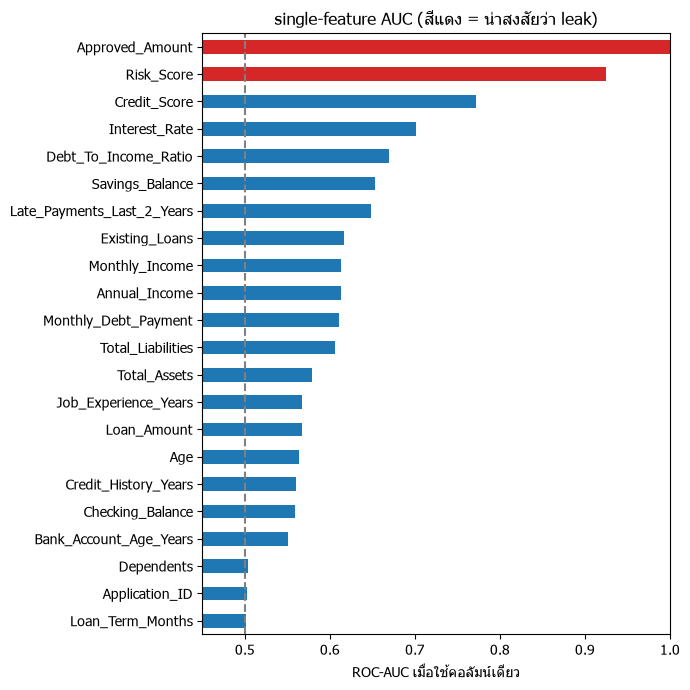

In [4]:
y_all = F.encode_target(df[F.TARGET])
single_auc = {}
for c in df.select_dtypes("number").columns:
    a = roc_auc_score(y_all, df[c])
    single_auc[c] = max(a, 1 - a)          # สนใจแค่ว่าแยกได้ดีแค่ไหน ไม่สนทิศ
single_auc = pd.Series(single_auc).sort_values()

ax = single_auc.plot.barh(figsize=(7, 7), color=["tab:red" if v > 0.9 else "tab:blue" for v in single_auc])
ax.axvline(0.5, ls="--", c="gray"); ax.set_xlabel("ROC-AUC เมื่อใช้คอลัมน์เดียว"); ax.set_xlim(0.45, 1.0)
plt.title("single-feature AUC (สีแดง = น่าสงสัยว่า leak)"); plt.tight_layout(); plt.show()

In [5]:
# ยืนยันด้วยตาราง: Approved_Amount ของคนที่ถูกปฏิเสธเป็น 0 ทุกแถวหรือไม่ และ Default_Risk สัมพันธ์กับผลแค่ไหน
print("Approved_Amount ของคำขอที่ถูกปฏิเสธ: min =", df.loc[y_all == 0, "Approved_Amount"].min(),
      " max =", df.loc[y_all == 0, "Approved_Amount"].max())
pd.crosstab(df["Default_Risk"], df[F.TARGET], normalize="index").round(3)

Approved_Amount ของคำขอที่ถูกปฏิเสธ: min = 0.0  max = 0.0


Loan_Approved,Approved,Rejected
Default_Risk,,
High,0.049,0.951
Low,0.963,0.037
Medium,0.583,0.417


**การตัดสินใจเรื่องคอลัมน์** (ใส่ไว้ใน `src/features.py` ให้ทุกส่วนของระบบใช้รายการเดียวกัน)

| คอลัมน์ | ตัดสินใจ | เหตุผล |
|---|---|---|
| `Approved_Amount` | **ตัด** | ผู้ถูกปฏิเสธมีค่า 0 ทุกแถว = ตัวคำตอบ (AUC 1.0) รู้ได้หลังอนุมัติแล้วเท่านั้น |
| `Default_Risk`, `Interest_Rate` | **ตัด** | ธนาคารกำหนดให้ *หลัง* ประเมินคำขอ ตอนลูกค้ายื่นยังไม่มีค่านี้ |
| `Risk_Score` | **ตัดสินจากการทดลองในหัวข้อ 6** | AUC ตัวเดียว ~0.93 เป็นคะแนนจากระบบอื่นที่ไม่รู้สูตร |
| `Gender`, `Marital_Status` | **ไม่ใช้เป็นฟีเจอร์** | ข้อมูลอ่อนไหว ไม่ควรใช้ตัดสินสินเชื่อ แต่เก็บไว้ตรวจ fairness |
| `Monthly_Income` | **ไม่ใช้เป็นฟีเจอร์** | ซ้ำกับ `Annual_Income/12` แบบเป๊ะ ใช้เป็นกฎตรวจความสอดคล้องแทน |
| `Application_ID` | **ตัด** | เป็นแค่เลขรัน |

## 3. แบ่งข้อมูล (Split) ให้มีเหตุผลและทำซ้ำได้

ข้อมูลชุดนี้ **ไม่มีคอลัมน์เวลา** จึงแบ่งตามเวลาไม่ได้ เราแบ่งแบบสุ่มโดยรักษาสัดส่วนคลาส (`stratify`) และล็อก `random_state=42`

| ส่วน | สัดส่วน | ใช้ทำอะไร |
|---|---|---|
| train | 50% | เทรนโมเดล และสร้าง schema |
| validation | 15% | เทียบโมเดลหลายตัว + เลือก threshold (**ห้าม** ใช้ test ทำสิ่งนี้) |
| test | 15% | วัดผลครั้งสุดท้ายที่ด่านตรวจ ดูครั้งเดียว |
| pool | 20% | กันไว้เป็น "ข้อมูล production ในอนาคต" สำหรับจำลอง drift ในหัวข้อ 9 (แนวเดียวกับ Lab 10) |

In [6]:
train_df, rest = train_test_split(df, test_size=0.50, random_state=SEED, stratify=df[F.TARGET])
val_df, rest   = train_test_split(rest, test_size=0.70, random_state=SEED, stratify=rest[F.TARGET])
test_df, pool_df = train_test_split(rest, test_size=0.20 / 0.35, random_state=SEED, stratify=rest[F.TARGET])

for name, part in [("train", train_df), ("val", val_df), ("test", test_df), ("pool", pool_df)]:
    part.to_csv(ARTIFACTS / f"{name}.csv", index=False)
    print(f"{name:5s} {len(part):6,d} แถว   อนุมัติ {F.encode_target(part[F.TARGET]).mean():.3f}")

# ทดสอบว่าทำซ้ำได้จริง: แบ่งใหม่อีกรอบต้องได้ ID ชุดเดิมทุกตัว
again, _ = train_test_split(df, test_size=0.50, random_state=SEED, stratify=df[F.TARGET])
print("\nแบ่งซ้ำได้ train ชุดเดิม:", again["Application_ID"].equals(train_df["Application_ID"]))

train 15,000 แถว   อนุมัติ 0.576
val    4,500 แถว   อนุมัติ 0.576


test   4,499 แถว   อนุมัติ 0.576
pool   6,001 แถว   อนุมัติ 0.576

แบ่งซ้ำได้ train ชุดเดิม: True


## 4. StatisticsGen → SchemaGen → ExampleValidator

- **Schema** คือ "สัญญา" ว่าข้อมูลที่ถูกต้องต้องหน้าตาแบบไหน สร้างจาก train ครั้งเดียวแล้วเก็บเป็น `schema.json`
  (ถ้าสร้างใหม่ทุกรอบ ข้อมูลเสียจะกลายเป็นมาตรฐานใหม่เอง อันนี้เป็นบทเรียนจาก Lab 11)
- กฎการตรวจอยู่ใน `src/validation.py` มี 2 แบบ
  1. **เรียนจากข้อมูล**: ช่วง min–max ของ train เผื่อ 20%, ค่าหมวดหมู่ที่เคยเห็น
  2. **ความรู้โดเมน** (ผิดคือผิด ไม่เผื่อ): `Credit_Score` ต้องอยู่ใน 300–850, อายุ ≥ 18, เงินห้ามติดลบ,
     `Monthly_Income = Annual_Income/12`, ค่าว่างต่อคอลัมน์ ≤ 5%, ID ห้ามซ้ำ

In [7]:
schema = V.build_schema(train_df, target=F.TARGET)
V.save_schema(schema, ARTIFACTS / "schema.json")
print("จำนวนคอลัมน์ตัวเลขใน schema :", len(schema["numeric"]))
print("จำนวนคอลัมน์หมวดหมู่ใน schema:", len(schema["categorical"]))
print("ตัวอย่าง:", json.dumps({"Credit_Score": schema["numeric"]["Credit_Score"],
                               "Employment_Status": schema["categorical"]["Employment_Status"]}, ensure_ascii=False))

จำนวนคอลัมน์ตัวเลขใน schema : 22
จำนวนคอลัมน์หมวดหมู่ใน schema: 13
ตัวอย่าง: {"Credit_Score": {"min": 340.0, "max": 850.0}, "Employment_Status": {"domain": ["Business Owner", "Contract", "Salaried", "Self-Employed", "Unemployed"]}}


In [8]:
# ข้อมูลดี: ทุกชุดต้องผ่าน
for name, part in [("train", train_df), ("val", val_df), ("test", test_df), ("pool", pool_df)]:
    print(f"{name:5s} →", V.validate(part, schema) or "ผ่าน ✅")

train → ผ่าน ✅
val   → ผ่าน ✅
test  → ผ่าน ✅
pool  → ผ่าน ✅


### 4.1 สาธิตข้อมูลเสีย: pipeline ต้อง "หยุด" และ "แจ้งเตือน"

เราจำลองข้อมูลเสียหลายแบบที่เจอได้จริง (แนวเดียวกับ `make_bad_data.py` ใน Lab 11) แล้วส่งเข้า `validate_or_raise`
ฟังก์ชันนี้จะ **โยน exception** ออกมา ซึ่งใน Airflow จะทำให้ task ล้มเป็นสีแดง และ task ที่ตามมา (เทรน, deploy) จะไม่ถูกรัน

ใน notebook เราใช้ `try/except` ดักไว้เพื่อให้เห็นข้อความแจ้งเตือน แต่ notebook ยังรันต่อได้

In [9]:
def make_bad_data(good: pd.DataFrame) -> pd.DataFrame:
    bad = good.sample(2000, random_state=SEED).copy()
    bad.loc[bad.index[:30], "Credit_Score"] = 920                  # เกินช่วง 300–850 (ระบบต้นทางส่งผิดสเกล)
    bad.loc[bad.index[30:60], "Annual_Income"] *= -1               # รายได้ติดลบ (bug ตอนแปลงข้อมูล)
    bad.loc[bad.index[60:90], "Employment_Status"] = "Freelancer"  # หมวดใหม่ที่ไม่เคยเห็น
    bad.loc[bad.index[:300], "Savings_Balance"] = np.nan           # ค่าว่าง 15% (ระบบบัญชีล่ม)
    bad = bad.drop(columns=["Collateral"])                         # คอลัมน์หาย (schema ต้นทางเปลี่ยน)
    return bad

bad_df = make_bad_data(train_df)

def pipeline_step_validate(batch: pd.DataFrame, name: str):
    try:
        V.validate_or_raise(batch, schema)
        print(f"[{name}] ✅ ผ่าน → ไปขั้นเทรนต่อ")
    except V.DataValidationError as e:
        print(f"[{name}] 🛑 PIPELINE หยุด: ไม่เทรน ไม่ deploy")
        print(f"🔔 ALERT: {e}")

pipeline_step_validate(train_df, "ข้อมูลปกติ")
print()
pipeline_step_validate(bad_df, "ข้อมูลเสีย")

[ข้อมูลปกติ] ✅ ผ่าน → ไปขั้นเทรนต่อ

[ข้อมูลเสีย] 🛑 PIPELINE หยุด: ไม่เทรน ไม่ deploy
🔔 ALERT: ข้อมูลไม่ผ่านการตรวจ:
  - ขาดคอลัมน์ที่ schema กำหนด: ['Collateral']
  - Annual_Income: พบค่าติดลบ -162697 ทั้งที่ห้ามติดลบ
  - Credit_Score: ผิดกฎโดเมน ต้องอยู่ใน [300, 850] แต่พบ 370 ถึง 920
  - Savings_Balance: ค่าว่าง 15.0% เกินเกณฑ์ 5%
  - Employment_Status: พบหมวดที่ไม่เคยเห็น ['Freelancer']
  - Monthly_Income ไม่เท่ากับ Annual_Income/12 จำนวน 30 แถว


## 5. Transform: การแปลงข้อมูลชุดเดียว ใช้ทั้งตอนเทรนและตอนให้บริการ

**ปัญหา Training-Serving Skew**: ถ้าตอนเทรนแปลงข้อมูลแบบหนึ่ง แต่ตอนให้บริการแปลงอีกแบบ (เช่น ลืม scale หรือใช้ median คนละค่า)
โมเดลจะทำนายเพี้ยนแบบเงียบ ๆ ไม่มี error ให้เห็น (Lab 7 ถามเรื่องนี้ตอนบันทึก `scaler.joblib`)

**กลไกป้องกันของเรา**
1. การแปลงทุกอย่างเขียนไว้ใน `src/features.py` **ไฟล์เดียว** ทั้ง notebook/DAG และ Flask API import ไฟล์นี้
2. การแปลงอยู่ใน sklearn `Pipeline` **ก้อนเดียวกับโมเดล** ค่าที่ต้อง "เรียน" (median, ขอบ outlier, หมวดของ one-hot)
   ถูก fit จาก train แล้วติดไปกับโมเดล พอ API โหลดโมเดลก็ได้ค่าชุดเดียวกันไปด้วยอัตโนมัติ
3. มีการทดสอบในหัวข้อ 8 ว่าผลทำนายจากโมเดลที่โหลดจาก Registry เท่ากับผลตอนเทรนทุกแถว

**ลำดับขั้นใน Pipeline**
```
LoanFeatureEngineer         สร้าง Loan_To_Income, Liability_To_Asset → clip outlier ที่ quantile 1%/99% ของ train
ColumnTransformer
 ├─ ตัวเลข:  SimpleImputer(median) → StandardScaler
 └─ หมวดหมู่: SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown="ignore")
โมเดล (LogisticRegression / RandomForest / HistGradientBoosting)
```
ดูโค้ดจริงได้จากเซลล์ข้างล่าง

In [10]:
import inspect
print(inspect.getsource(F.LoanFeatureEngineer))
print(inspect.getsource(F.build_pipeline))

class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    """ขั้นแรกของ Pipeline: สร้างฟีเจอร์อัตราส่วน แล้วตัดค่าผิดปกติ (outlier) ด้วยขอบที่เรียนจากชุด train

    - fit()      : จำขอบล่าง/บน (quantile 1% และ 99%) ของทุกคอลัมน์ตัวเลข จากชุด train เท่านั้น
    - transform(): ใช้ขอบที่จำไว้ตัดค่าที่ล้นออกไป (clip) ทั้งตอนเทรนและตอนให้บริการ

    ทำไมต้อง clip แทนการลบแถวทิ้ง: ตอนให้บริการเราลบคำขอของลูกค้าทิ้งไม่ได้ ต้องตอบทุกคำขอ
    ค่าว่าง (NaN) ปล่อยผ่านไปก่อน ให้ SimpleImputer ในขั้นถัดไปเติม
    """

    def __init__(self, numeric_cols=None, lower_q=0.01, upper_q=0.99):
        self.numeric_cols = numeric_cols
        self.lower_q = lower_q
        self.upper_q = upper_q

    @staticmethod
    def _add_ratios(X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        # หารด้วย 0 จะได้ inf → เปลี่ยนเป็น NaN ให้ imputer จัดการ
        X["Loan_To_Income"] = (X["Loan_Amount"] / X["Annual_Income"]).replace([np.inf, -np.inf], np.nan)
        X["Liability_To_Asset"] = (X["Total

In [11]:
X_train, y_train = train_df, F.encode_target(train_df[F.TARGET])
X_val,   y_val   = val_df,   F.encode_target(val_df[F.TARGET])
X_test,  y_test  = test_df,  F.encode_target(test_df[F.TARGET])

# ลองดูว่า Pipeline แปลงข้อมูลออกมาหน้าตาแบบไหน (ยังไม่มีโมเดล ใช้ Dummy แทน)
demo = F.build_pipeline(DummyClassifier()).fit(X_train, y_train)
Xt = demo[:-1].transform(X_val.head(3))
print("หลังแปลงได้", Xt.shape[1], "คอลัมน์ (ตัวเลข+ฟีเจอร์ใหม่ =", len(F.NUMERIC) + len(F.ENGINEERED), ", ที่เหลือคือ one-hot)")
print("ขอบ clip ที่เรียนจาก train ของ Annual_Income:", demo.named_steps["features"].bounds_["Annual_Income"])

หลังแปลงได้

 59 คอลัมน์ (ตัวเลข+ฟีเจอร์ใหม่ = 19 , ที่เหลือคือ one-hot)
ขอบ clip ที่เรียนจาก train ของ Annual_Income: (20290.680800000002, 161360.47770000002)


## 6. Trainer + Experiment Tracking ด้วย MLflow

ทุกการทดลองต้องบันทึกให้ครบ **6 อย่าง** ตามที่โจทย์กำหนด

| สิ่งที่ต้องบันทึก | บันทึกอย่างไร |
|---|---|
| 1. เวอร์ชันโค้ด | tag `git_commit` (ถ้ายังไม่อยู่ใน git จะเป็น `no-git`, พอขึ้น GitHub แล้วจะเป็นเลข commit จริง) |
| 2. เวอร์ชันข้อมูล | param `data_md5` + จำนวนแถว train |
| 3. ไฮเปอร์พารามิเตอร์ | `log_params(clf.get_params())` |
| 4. ตัวชี้วัด | ROC-AUC, F1, accuracy, recall ของคลาสปฏิเสธ (บน validation) |
| 5. ไฟล์ผลลัพธ์ | ตัวโมเดล (`log_model`), รูป confusion matrix, รายชื่อฟีเจอร์ |
| 6. สภาพแวดล้อม | `environment.json` (Python, OS, เวอร์ชันไลบรารี) + ไฟล์ `uv.lock` |

ใช้ MLflow แบบ Lab 9: เก็บ metadata ใน `mlflow.db` (SQLite) และเปิดดูหน้าเว็บได้ด้วย
`uv run mlflow ui --backend-store-uri sqlite:///mlflow.db`

In [12]:
mlflow.set_tracking_uri(f"sqlite:///{(ROOT / 'mlflow.db').as_posix()}")
EXPERIMENT = "loan-approval-notebook"
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=(ROOT / "mlruns").as_uri())
mlflow.set_experiment(EXPERIMENT)

# MLflow 3 บันทึกโมเดลด้วยรูปแบบ skops ซึ่งปลอดภัยกว่า pickle: จะยอมโหลดเฉพาะคลาสที่เราประกาศว่า "ไว้ใจ"
# คลาสของเราเอง (LoanFeatureEngineer) จึงต้องใส่ไว้ในรายการนี้
# และโครงสร้างต้นไม้ของ RandomForest / HistGradientBoosting ซึ่งเราเทรนเองจึงไว้ใจได้
TRUSTED_TYPES = ["src.features.LoanFeatureEngineer", "numpy.dtype", "sklearn.tree._tree.Tree",
                 "sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor"]

def git_commit():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return "no-git"

ENV_INFO = {"python": platform.python_version(), "os": platform.platform(),
            **{lib: version(lib) for lib in ["scikit-learn", "pandas", "numpy", "mlflow", "scipy"]}}
(ARTIFACTS / "environment.json").write_text(json.dumps(ENV_INFO, indent=2))

def evaluate(model, X, y, threshold=0.5):
    p = model.predict_proba(X)[:, 1]
    pred = (p >= threshold).astype(int)
    return {"roc_auc": roc_auc_score(y, p), "f1": f1_score(y, pred), "accuracy": accuracy_score(y, pred),
            "recall_rejected": recall_score(1 - y, 1 - pred)}   # recall ของคลาส "ปฏิเสธ"

def run_experiment(name, clf, numeric_cols=None, note=""):
    # เทรน 1 การทดลอง แล้วบันทึกครบ 6 อย่างลง MLflow
    numeric_cols = list(numeric_cols or F.NUMERIC)
    with mlflow.start_run(run_name=name) as run:
        model = F.build_pipeline(clf, numeric_cols=numeric_cols)
        t0 = time.perf_counter(); model.fit(X_train, y_train); fit_s = time.perf_counter() - t0
        m = evaluate(model, X_val, y_val)

        mlflow.set_tags({"git_commit": git_commit(), "note": note, "stage": "experiment"})       # (1)
        mlflow.log_params({"data_md5": DATA_VERSION, "n_train": len(X_train)})                    # (2)
        mlflow.log_params({"model_type": type(clf).__name__, "use_risk_score": "Risk_Score" in numeric_cols,
                           **{f"clf__{k}": v for k, v in clf.get_params().items()}})              # (3)
        mlflow.log_metrics({**{f"val_{k}": v for k, v in m.items()}, "fit_seconds": fit_s})      # (4)

        fig, ax = plt.subplots(figsize=(4, 4))                                                    # (5)
        ConfusionMatrixDisplay.from_predictions(y_val, model.predict(X_val),
                                                display_labels=["Rejected", "Approved"], ax=ax, colorbar=False)
        ax.set_title(name); mlflow.log_figure(fig, "confusion_matrix.png"); plt.close(fig)
        mlflow.log_dict({"numeric": numeric_cols, "categorical": F.CATEGORICAL, "engineered": F.ENGINEERED}, "features.json")
        info = mlflow.sklearn.log_model(sk_model=model, name="model", input_example=X_train[numeric_cols + F.CATEGORICAL].head(3),
                                 code_paths=[str(ROOT / "src")],   # แนบ src/ ไปด้วย ให้โหลดโมเดลที่ไหนก็ได้
                                 skops_trusted_types=TRUSTED_TYPES)
        mlflow.log_artifact(str(ARTIFACTS / "environment.json"))                                  # (6)
        if (ROOT / "uv.lock").exists():
            mlflow.log_artifact(str(ROOT / "uv.lock"))
    print(f"{name:32s} AUC={m['roc_auc']:.4f}  F1={m['f1']:.4f}  recall_rej={m['recall_rejected']:.4f}  ({fit_s:.1f}s)")
    return model, info.model_uri, m     # model_uri ใช้ตอนลงทะเบียนใน registry

### 6.1 การทดลอง (อย่างน้อย 3 รอบ ตามโจทย์)

| # | การทดลอง | คำถามที่อยากตอบ |
|---|---|---|
| E0 | Dummy (ทายคลาสที่เยอะสุดเสมอ) | ถ้าไม่ฉลาดเลยจะได้เท่าไร = พื้นขั้นต่ำ |
| E1 | Logistic Regression **ใส่** `Risk_Score` | `Risk_Score` ช่วยมากแค่ไหน |
| E2 | Logistic Regression **ไม่ใส่** `Risk_Score` | baseline ที่ใช้งานได้จริง |
| E3 | Logistic Regression C=0.1 (regularize แรงขึ้น) | จูน hyperparameter |
| E4 | Random Forest | โมเดลไม่เป็นเส้นตรงช่วยไหม |
| E5 | HistGradientBoosting (ตัวเดียวกับ Lab 11) | boosting ช่วยไหม |

In [13]:
results = {}
NUM_WITH_RISK = F.NUMERIC + ["Risk_Score"]
results["E0 dummy"]          = run_experiment("E0 dummy", DummyClassifier(strategy="most_frequent"), note="พื้นขั้นต่ำ")
results["E1 logreg +risk"]   = run_experiment("E1 logreg +risk", LogisticRegression(max_iter=2000), NUM_WITH_RISK, note="ablation: ใส่ Risk_Score")
results["E2 logreg"]         = run_experiment("E2 logreg", LogisticRegression(max_iter=2000), note="baseline จริง")
results["E3 logreg C=0.1"]   = run_experiment("E3 logreg C=0.1", LogisticRegression(C=0.1, max_iter=2000), note="จูน C")
results["E4 random forest"]  = run_experiment("E4 random forest", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED))
results["E5 hist gboost"]    = run_experiment("E5 hist gboost", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=SEED))

E0 dummy                         AUC=0.5000  F1=0.7313  recall_rej=0.0000  (0.1s)


E1 logreg +risk                  AUC=0.9271  F1=0.8752  recall_rej=0.7980  (0.1s)


E2 logreg                        AUC=0.8940  F1=0.8438  recall_rej=0.7277  (0.1s)


E3 logreg C=0.1                  AUC=0.8940  F1=0.8455  recall_rej=0.7282  (0.2s)


E4 random forest                 AUC=0.8896  F1=0.8451  recall_rej=0.7256  (1.0s)


E5 hist gboost                   AUC=0.8959  F1=0.8445  recall_rej=0.7413  (0.4s)


,val_auc,val_f1,val_recall_rej,fit_s,use_risk,data_md5
tags.mlflow.runName,,,,,,
E0 dummy,0.5000,0.7313,0.0000,0.0938,False,821a619be3c1c82708fc549fa0afd635
E1 logreg +risk,0.9271,0.8752,0.7980,0.1150,True,821a619be3c1c82708fc549fa0afd635
E2 logreg,0.8940,0.8438,0.7277,0.1076,False,821a619be3c1c82708fc549fa0afd635
E3 logreg C=0.1,0.8940,0.8455,0.7282,0.2222,False,821a619be3c1c82708fc549fa0afd635
E4 random forest,0.8896,0.8451,0.7256,0.9965,False,821a619be3c1c82708fc549fa0afd635
E5 hist gboost,0.8959,0.8445,0.7413,0.4118,False,821a619be3c1c82708fc549fa0afd635
R1 retrain on W3,NaN,NaN,NaN,NaN,NaN,821a619be3c1c82708fc549fa0afd635


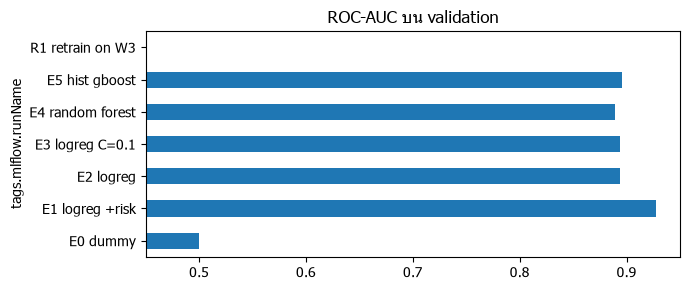

In [14]:
# ดึงผลทุกการทดลองกลับมาจาก MLflow เพื่อเปรียบเทียบข้ามการทดลอง (เหมือนหน้า Compare ใน MLflow UI)
runs = mlflow.search_runs(experiment_names=[EXPERIMENT], order_by=["start_time DESC"])
cmp = (runs.drop_duplicates("tags.mlflow.runName")
           .set_index("tags.mlflow.runName")[["metrics.val_roc_auc", "metrics.val_f1", "metrics.val_recall_rejected",
                                              "metrics.fit_seconds", "params.use_risk_score", "params.data_md5"]]
           .sort_index())
cmp.columns = ["val_auc", "val_f1", "val_recall_rej", "fit_s", "use_risk", "data_md5"]
display(cmp.round(4))
cmp["val_auc"].plot.barh(figsize=(7, 3), xlim=(0.45, 0.95), title="ROC-AUC บน validation"); plt.tight_layout(); plt.show()

### 6.2 ตัดสินใจจากผลการทดลอง

1. **E0 → E2:** ไม่ใช้ `Risk_Score` ก็ได้ AUC ~0.89 เทียบกับ 0.5 ของ dummy แปลว่าโมเดลเรียนรู้ได้จริง
2. **`Risk_Score` (E1 เทียบ E2):** เพิ่ม AUC ได้ ~0.03 แต่ **เราเลือกไม่ใช้** เพราะ
   - เป็นคะแนนจากระบบอื่นที่ไม่รู้สูตร และสูตรอาจใช้ข้อมูลหลังการตัดสินใจ (เสี่ยง leakage)
   - ถ้าระบบนั้นเปลี่ยนสูตร โมเดลเราจะพังตามโดยที่เราไม่รู้ตัว (เป็น dependency ที่คุมไม่ได้)
   - ระบบเราควรทำงานได้ด้วยข้อมูลที่ลูกค้ากรอกเอง
3. **เลือกโมเดล:** โมเดลที่ซับซ้อนกว่า **ดีขึ้นแทบไม่มีนัยสำคัญ** (HistGradientBoosting ดีกว่าแค่ ~0.002, Random Forest แย่กว่า)
   จึงเลือก **Logistic Regression (E2)** เพราะ
   - แม่นใกล้เคียงกัน แต่เทรนเร็วกว่า ~4 เท่า ทำนายเร็ว และไฟล์เล็กมาก (จะเห็นในหัวข้อ 9 ว่า RF ใหญ่ ~50 MB และช้า)
   - อธิบายได้ (มี coefficient) ซึ่งสำคัญมากสำหรับงานสินเชื่อ ที่ต้องบอกลูกค้าได้ว่าทำไมถูกปฏิเสธ

In [15]:
CHOSEN = "E2 logreg"
model, chosen_uri, _ = results[CHOSEN]
print("โมเดลที่เลือก:", CHOSEN, "| model uri:", chosen_uri)

โมเดลที่เลือก: E2 logreg | model uri: models:/m-674f5743aea442d6bb4d0feacf79b296


## 7. เลือก Threshold ด้วยต้นทุนทางธุรกิจ + รูปแบบ Cascade

ค่า default 0.5 ไม่ได้คิดเรื่องต้นทุน ในงานสินเชื่อ **อนุมัติผิดคน แพงกว่าปฏิเสธผิดคน**
(ตั้งไว้ 3 : 1 ในเซลล์ setup) เราจึงหา threshold ที่ทำให้ต้นทุนรวมบน **validation** ต่ำที่สุด

จากนั้นใช้รูปแบบ **Cascade** (Lab 7 / Exercise 04) ในการให้บริการ
```
คำขอ → [ตรวจ schema] ─ผิด→ ตอบ 400 (ไม่ทำนาย)
          │ ผ่าน
          ▼
      [โมเดล] ─ p สูงมาก → อนุมัติอัตโนมัติ
              ─ p ต่ำมาก  → ปฏิเสธอัตโนมัติ
              ─ ก้ำกึ่ง    → ส่งเจ้าหน้าที่พิจารณา (human-in-the-loop)
```

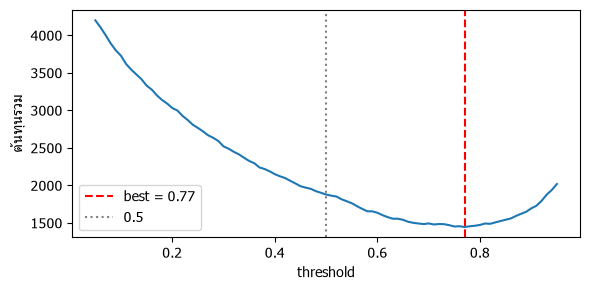

threshold ที่ต้นทุนต่ำสุด = 0.77   ต้นทุนที่ 0.5 = 1879   ที่ 0.77 = 1446
ผลที่ threshold ใหม่: {'roc_auc': 0.894, 'f1': 0.7586, 'accuracy': 0.76, 'recall_rejected': 0.904}


In [16]:
p_val = model.predict_proba(X_val)[:, 1]
ths = np.round(np.arange(0.05, 0.96, 0.01), 2)

def business_cost(y, p, t):
    pred = (p >= t).astype(int)
    false_approve = int(((pred == 1) & (y == 0)).sum())
    false_reject  = int(((pred == 0) & (y == 1)).sum())
    return COST_FALSE_APPROVE * false_approve + COST_FALSE_REJECT * false_reject

costs = [business_cost(y_val.values, p_val, t) for t in ths]
THRESHOLD = float(ths[int(np.argmin(costs))])

plt.figure(figsize=(6, 3)); plt.plot(ths, costs); plt.axvline(THRESHOLD, c="r", ls="--", label=f"best = {THRESHOLD}")
plt.axvline(0.5, c="gray", ls=":", label="0.5"); plt.xlabel("threshold"); plt.ylabel("ต้นทุนรวม"); plt.legend(); plt.tight_layout(); plt.show()
print(f"threshold ที่ต้นทุนต่ำสุด = {THRESHOLD}   ต้นทุนที่ 0.5 = {business_cost(y_val.values, p_val, 0.5)}   ที่ {THRESHOLD} = {min(costs)}")
print("ผลที่ threshold ใหม่:", {k: round(v, 4) for k, v in evaluate(model, X_val, y_val, THRESHOLD).items()})

In [17]:
# โซนก้ำกึ่ง: กว้าง ±0.10 รอบ threshold → ดูว่าระบบตัดสินอัตโนมัติได้กี่ % และแม่นแค่ไหนในส่วนนั้น
GRAY = 0.10
auto = (p_val < THRESHOLD - GRAY) | (p_val >= THRESHOLD + GRAY)
auto_acc = accuracy_score(y_val[auto], (p_val[auto] >= THRESHOLD).astype(int))
print(f"ตัดสินอัตโนมัติได้ {auto.mean():.1%} ของคำขอ  | ความแม่นในส่วนอัตโนมัติ {auto_acc:.1%}")
print(f"ส่งให้เจ้าหน้าที่ {1 - auto.mean():.1%} ของคำขอ")

ตัดสินอัตโนมัติได้ 78.5% ของคำขอ  | ความแม่นในส่วนอัตโนมัติ 80.3%
ส่งให้เจ้าหน้าที่ 21.5% ของคำขอ


**เชื่อมกับตัวชี้วัดทางธุรกิจ**
- **% คำขอที่ตัดสินอัตโนมัติ** → ลดงานเจ้าหน้าที่ ลดเวลารอของลูกค้า
- **ความแม่นในโซนอัตโนมัติ** → คุมความเสี่ยงของการตัดสินผิดโดยไม่มีคนดู
- **ต้นทุนรวม (3 : 1)** → แทนความเสียหายจากหนี้เสียเทียบกับรายได้ที่เสียไป
- ตัวชี้วัดของโมเดล: **Optimizing = ROC-AUC** (ยิ่งสูงยิ่งดี) · **Gating = AUC ≥ 0.85, recall ปฏิเสธ ≥ 0.80, p95 latency, ขนาดไฟล์**

## 8. Evaluator: ด่านตรวจก่อนอนุมัติขึ้นใช้งาน (Gate) + อธิบายผล + Fairness

ใช้ **test set ครั้งแรกและครั้งเดียว** ที่นี่ โมเดลต้องผ่านทุกข้อจึงจะได้ "blessed" (คำเรียกของ TFX Evaluator ใน Lab 11)

In [18]:
def measure_latency_ms(m, X, n=300):
    # วัดเวลาทำนายทีละ 1 คำขอ n ครั้ง → คืน p50, p95 (มิลลิวินาที)
    rows = [X.iloc[[i % len(X)]] for i in range(n)]
    m.predict_proba(rows[0])                       # warm-up รอบแรกไม่นับ
    t = []
    for r in rows:
        t0 = time.perf_counter(); m.predict_proba(r); t.append((time.perf_counter() - t0) * 1000)
    return float(np.percentile(t, 50)), float(np.percentile(t, 95)), t

def model_size_mb(m):
    path = ARTIFACTS / "_size_check.joblib"; joblib.dump(m, path)
    return path.stat().st_size / 1e6

def gate(m, X, y, threshold, champion_auc=None):
    met = evaluate(m, X, y, threshold)
    p50, p95, _ = measure_latency_ms(m, X)
    checks = {
        f"ROC-AUC ≥ {MIN_ROC_AUC}":                (met["roc_auc"], met["roc_auc"] >= MIN_ROC_AUC),
        f"recall ปฏิเสธ ≥ {MIN_RECALL_REJECTED}":     (met["recall_rejected"], met["recall_rejected"] >= MIN_RECALL_REJECTED),
        f"p95 latency ≤ {MAX_P95_LATENCY_MS} ms":   (p95, p95 <= MAX_P95_LATENCY_MS),
        f"ขนาดโมเดล ≤ {MAX_MODEL_SIZE_MB} MB":      (model_size_mb(m), model_size_mb(m) <= MAX_MODEL_SIZE_MB),
    }
    if champion_auc is not None:
        diff = met["roc_auc"] - champion_auc
        checks[f"ไม่แย่กว่า champion เกิน {abs(MIN_IMPROVEMENT)}"] = (diff, diff >= MIN_IMPROVEMENT)
    table = pd.DataFrame([(k, round(v, 4), "✅" if ok else "❌") for k, (v, ok) in checks.items()],
                         columns=["เกณฑ์", "ค่าที่ได้", "ผ่าน"])
    return all(ok for _, ok in checks.values()), met, table

blessed, test_metrics, gate_table = gate(model, X_test, y_test, THRESHOLD)
display(gate_table)
print("BLESSED ✅ อนุมัติขึ้นใช้งานได้" if blessed else "NOT BLESSED ❌ ห้ามขึ้นใช้งาน")

,เกณฑ์,ค่าที่ได้,ผ่าน
0,ROC-AUC ≥ 0.85,0.8969,✅
1,recall ปฏิเสธ ≥ 0.8,0.9182,✅
2,p95 latency ≤ 50.0 ms,28.1154,✅
3,ขนาดโมเดล ≤ 50.0 MB,0.0096,✅


BLESSED ✅ อนุมัติขึ้นใช้งานได้


### 8.1 อธิบายผล: โมเดลดูฟีเจอร์อะไร

ใช้ 2 วิธีที่เรียนมาแล้ว
1. **Permutation importance** (Lab 6): สุ่มสลับค่าฟีเจอร์ทีละตัว ถ้า AUC ตกมาก แปลว่าฟีเจอร์นั้นสำคัญ
2. **Coefficient ของ Logistic Regression**: ค่าบวกดันไปทาง "อนุมัติ" ค่าลบดันไปทาง "ปฏิเสธ" (ข้อมูลผ่านการ scale แล้วจึงเทียบขนาดกันได้)

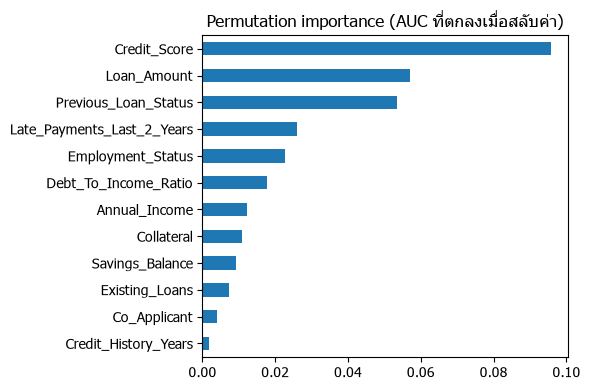

ดันไปทาง 'ปฏิเสธ' มากสุด:
 cat__Previous_Loan_Status_Defaulted   -2.616
cat__Employment_Status_Unemployed     -1.783
num__Late_Payments_Last_2_Years       -0.669
num__Loan_To_Income                   -0.600
num__Debt_To_Income_Ratio             -0.472

ดันไปทาง 'อนุมัติ' มากสุด:
 cat__Employment_Status_Business Owner         0.511
cat__Previous_Loan_Status_No Previous Loan    0.567
cat__Previous_Loan_Status_Active              0.570
num__Credit_Score                             1.137
cat__Previous_Loan_Status_Paid Off            1.357


In [19]:
cols_in = F.NUMERIC + F.CATEGORICAL
pi = permutation_importance(model, X_val[cols_in], y_val, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=cols_in).sort_values().tail(12)
imp.plot.barh(figsize=(6, 4), title="Permutation importance (AUC ที่ตกลงเมื่อสลับค่า)"); plt.tight_layout(); plt.show()

names = model.named_steps["pre"].get_feature_names_out()
coef = pd.Series(model.named_steps["clf"].coef_[0], index=names).sort_values()
print("ดันไปทาง 'ปฏิเสธ' มากสุด:\n", coef.head(5).round(3).to_string())
print("\nดันไปทาง 'อนุมัติ' มากสุด:\n", coef.tail(5).round(3).to_string())

### 8.2 Fairness: โมเดลปฏิบัติต่อแต่ละเพศต่างกันไหม
เราไม่ได้ใส่ `Gender` เป็นฟีเจอร์ แต่ฟีเจอร์อื่นอาจสัมพันธ์กับเพศแฝงอยู่ จึงต้องวัดแยกกลุ่ม (แนวเดียวกับ `fairness_audit` ใน Lab 11)

In [20]:
t = X_test.assign(y=y_test, p=model.predict_proba(X_test)[:, 1])
fair = t.groupby("Gender").apply(lambda g: pd.Series({
    "n": len(g), "อัตราอนุมัติจริง": g.y.mean(), "อัตราอนุมัติที่โมเดลทาย": (g.p >= THRESHOLD).mean(),
    "roc_auc": roc_auc_score(g.y, g.p)})).round(4)
display(fair)
gap = fair["อัตราอนุมัติที่โมเดลทาย"].max() - fair["อัตราอนุมัติที่โมเดลทาย"].min()
print(f"ส่วนต่างอัตราอนุมัติ = {gap:.3f}  → {'ผ่าน ✅' if gap <= MAX_APPROVAL_GAP else 'ต้องตรวจเพิ่ม ⚠️'} (เกณฑ์ ≤ {MAX_APPROVAL_GAP})")

,n,อัตราอนุมัติจริง,อัตราอนุมัติที่โมเดลทาย,roc_auc
Gender,,,,
Female,1942.0,0.5798,0.4022,0.8968
Male,2557.0,0.5737,0.3962,0.8967


ส่วนต่างอัตราอนุมัติ = 0.006  → ผ่าน ✅ (เกณฑ์ ≤ 0.1)


## 9. Model Registry: เวอร์ชัน, สถานะ (alias) และการย้อนกลับ (Rollback)

ใช้ MLflow Model Registry แบบ Lab 9 โดยใช้ **alias** บอกสถานะของแต่ละเวอร์ชัน
- `@champion` = ตัวที่ให้บริการอยู่ (API โหลดผ่าน `models:/loan-approval-notebook@champion`)
- `@challenger` = ตัวใหม่ที่รอผ่านด่านตรวจ

**การ rollback** คือย้าย alias `@champion` กลับไปชี้เวอร์ชันเก่า API ไม่ต้อง build ใหม่ แค่โหลดโมเดลใหม่

> เพื่อให้ notebook รันซ้ำได้ผลเหมือนเดิม เราลบชื่อโมเดล demo นี้ก่อนเริ่ม (ใช้ชื่อแยกจากระบบจริง)

In [21]:
MODEL_NAME = "loan-approval-notebook"
client = MlflowClient()
try:
    client.delete_registered_model(MODEL_NAME)
except Exception:
    pass

def register(model_uri, alias, description):
    mv = mlflow.register_model(model_uri, MODEL_NAME)
    client.set_registered_model_alias(MODEL_NAME, alias, mv.version)
    client.set_model_version_tag(MODEL_NAME, mv.version, "description", description)
    return mv.version

def show_registry():
    rows = []
    for mv in client.search_model_versions(f"name='{MODEL_NAME}'"):
        aliases = [a for a, v in client.get_registered_model(MODEL_NAME).aliases.items() if v == mv.version]
        rows.append({"version": int(mv.version), "aliases": aliases, "description": mv.tags.get("description", "")})
    display(pd.DataFrame(rows).sort_values("version"))

# v1: โมเดลที่ผ่าน gate ในหัวข้อ 8 → ขึ้นเป็น champion
v1 = register(chosen_uri, "champion", f"{CHOSEN} | test AUC {test_metrics['roc_auc']:.4f}")
client.set_model_version_tag(MODEL_NAME, v1, "threshold", str(THRESHOLD))
show_registry()

Successfully registered model 'loan-approval-notebook'.
Created version '1' of model 'loan-approval-notebook'.


,version,aliases,description
0,1,[champion],E2 logreg | test AUC 0.8969


In [22]:
# v2: สมมติว่ามีคนส่งโมเดลใหม่ (Random Forest) เข้ามาเป็น challenger → ต้องผ่าน gate ก่อน
rf_model, rf_uri, _ = results["E4 random forest"]
v2 = register(rf_uri, "challenger", "E4 random forest")
ok, _, tbl = gate(rf_model, X_test, y_test, THRESHOLD, champion_auc=test_metrics["roc_auc"])
display(tbl)
print("challenger ผ่าน gate → promote" if ok else "challenger ไม่ผ่าน gate → champion ยังเป็นตัวเดิม ✅ (ระบบกันโมเดลที่แย่กว่าไม่ให้ขึ้น)")

Registered model 'loan-approval-notebook' already exists. Creating a new version of this model...
Created version '2' of model 'loan-approval-notebook'.


,เกณฑ์,ค่าที่ได้,ผ่าน
0,ROC-AUC ≥ 0.85,0.8919,✅
1,recall ปฏิเสธ ≥ 0.8,0.9491,✅
2,p95 latency ≤ 50.0 ms,171.9882,❌
3,ขนาดโมเดล ≤ 50.0 MB,50.6052,❌
4,ไม่แย่กว่า champion เกิน 0.003,-0.0050,❌


challenger ไม่ผ่าน gate → champion ยังเป็นตัวเดิม ✅ (ระบบกันโมเดลที่แย่กว่าไม่ให้ขึ้น)


In [23]:
# สาธิต ROLLBACK: สมมติว่ามีคน promote v2 ขึ้นไปแบบผิดพลาด (ข้ามด่าน) แล้วพบว่าผลแย่ลงใน production
client.set_registered_model_alias(MODEL_NAME, "champion", v2)
print("⚠️ promote ผิดพลาด → champion =", client.get_model_version_by_alias(MODEL_NAME, "champion").version)

def rollback(to_version):
    client.set_registered_model_alias(MODEL_NAME, "champion", to_version)
    print(f"↩️ ROLLBACK → champion = v{to_version}")

rollback(v1)
show_registry()

⚠️ promote ผิดพลาด → champion = 2
↩️ ROLLBACK → champion = v1


,version,aliases,description
1,1,[champion],E2 logreg | test AUC 0.8969
0,2,[challenger],E4 random forest


### 9.1 ตรวจ Training-Serving Skew: โหลดโมเดลจาก Registry แล้วต้องทำนายเหมือนตอนเทรนทุกแถว
นี่คือสิ่งที่ API จะทำจริง (โหลดผ่าน alias) ถ้าผลต่างเป็น 0 แปลว่าการแปลงข้อมูลตอนให้บริการตรงกับตอนเทรน

In [24]:
served = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@champion")
diff = np.abs(served.predict_proba(X_test)[:, 1] - model.predict_proba(X_test)[:, 1]).max()
print(f"ความต่างสูงสุดของความน่าจะเป็น (โมเดลที่เทรน vs โมเดลที่โหลดจาก registry) = {diff:.2e}")
assert diff < 1e-9, "Training-Serving Skew!"
print("✅ ไม่มี skew")

ความต่างสูงสุดของความน่าจะเป็น (โมเดลที่เทรน vs โมเดลที่โหลดจาก registry) = 0.00e+00
✅ ไม่มี skew


## 10. Serving (ต้นแบบ): ฟังก์ชันทำนาย + วัด Latency/Throughput + SLO

ในระบบจริงฟังก์ชันนี้จะอยู่ใน **Flask API ใน Docker** (แบบ Lab 3 / Lab 7) มี endpoint
`/health`, `/predict`, `/predict/batch`, `/metrics` ที่นี่เราลองตรรกะเดียวกันก่อน

**SLO ที่ประกาศ (ร่าง):** p95 latency ≤ 200 ms (รวม network ผ่าน API), error rate < 1%
ตัวเลขใน notebook คือเวลาในโปรเซสเท่านั้น ใช้ประมาณว่ามีเวลาเหลือให้ network/Flask เท่าไร

In [25]:
def predict_request(payload: dict) -> dict:
    # ตรรกะเดียวกับ /predict ใน Flask: ตรวจ schema → ทำนาย → cascade
    row = pd.DataFrame([payload])
    problems = V.validate(row, schema, batch=False)
    if problems:
        return {"status": 400, "errors": problems}
    p = float(served.predict_proba(row)[0, 1])
    if p >= THRESHOLD + GRAY:
        decision = "AUTO_APPROVE"
    elif p < THRESHOLD - GRAY:
        decision = "AUTO_REJECT"
    else:
        decision = "MANUAL_REVIEW"
    return {"status": 200, "probability_approve": round(p, 4), "decision": decision}

sample = X_test.drop(columns=[F.TARGET]).iloc[0].to_dict()
print("คำขอปกติ           →", predict_request(sample))
print("คำขอมีค่าว่าง (ยังตอบได้) →", predict_request({**sample, "Savings_Balance": None, "Region": None}))
print("คำขอเสีย            →", predict_request({**sample, "Credit_Score": 999, "Employment_Status": "Astronaut"}))

คำขอปกติ           → {'status': 200, 'probability_approve': 0.9693, 'decision': 'AUTO_APPROVE'}
คำขอมีค่าว่าง (ยังตอบได้) → {'status': 200, 'probability_approve': 0.967, 'decision': 'AUTO_APPROVE'}
คำขอเสีย            → {'status': 400, 'errors': ['Credit_Score: ผิดกฎโดเมน ต้องอยู่ใน [300, 850] แต่พบ 999 ถึง 999', "Employment_Status: พบหมวดที่ไม่เคยเห็น ['Astronaut']"]}


ทีละคำขอ : p50 = 19.74 ms   p95 = 27.74 ms   → throughput ≈ 53 คำขอ/วินาที (1 โปรเซส)
แบบ batch: 4,499 คำขอใน 22 ms → ≈ 205,530 คำขอ/วินาที


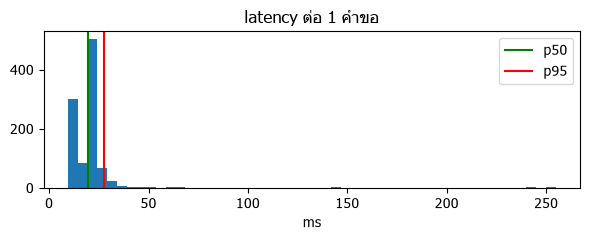

In [26]:
p50, p95, lat = measure_latency_ms(served, X_test, n=1000)
t0 = time.perf_counter(); served.predict_proba(X_test); batch_s = time.perf_counter() - t0
print(f"ทีละคำขอ : p50 = {p50:.2f} ms   p95 = {p95:.2f} ms   → throughput ≈ {1000 / np.mean(lat):,.0f} คำขอ/วินาที (1 โปรเซส)")
print(f"แบบ batch: {len(X_test):,} คำขอใน {batch_s * 1000:.0f} ms → ≈ {len(X_test) / batch_s:,.0f} คำขอ/วินาที")
plt.figure(figsize=(6, 2.5)); plt.hist(lat, bins=50); plt.axvline(p50, c="g", label="p50"); plt.axvline(p95, c="r", label="p95")
plt.xlabel("ms"); plt.legend(); plt.title("latency ต่อ 1 คำขอ"); plt.tight_layout(); plt.show()

**การเลือกรูปแบบการให้บริการ:** ใช้ **real-time** (ลูกค้ายื่นคำขอแล้วรอผลบนแอป/หน้าเคาน์เตอร์) ร่วมกับ **cascade**
ส่วนงานประมวลผลคำขอค้างตอนกลางคืนใช้ `/predict/batch` ซึ่งเร็วกว่าทีละคำขอหลายเท่า

## 11. Monitoring: แยก Data Drift กับ Concept Drift ให้ออก

| | Data Drift | Concept Drift |
|---|---|---|
| อะไรเปลี่ยน | **ข้อมูลเข้า** P(X) เช่น ลูกค้ารายได้น้อยมาสมัครมากขึ้น | **ความสัมพันธ์** P(y\|X) เช่น ธนาคารเปลี่ยนนโยบายการอนุมัติ |
| ตรวจยังไง | เทียบการกระจายตัวกับ train ได้ **ทันที ไม่ต้องรอเฉลย** (KS test ตัวเลข, Chi-square หมวดหมู่ แบบ Lab 11) | ต้อง **รอเฉลยจริง** แล้ววัด AUC เทียบกับตอน deploy |
| เกณฑ์แจ้งเตือน | ฟีเจอร์ drift (p < 0.01) เกิน 20% | AUC ตกเกิน 0.05 |

เราใช้ข้อมูล `pool` ที่กันไว้จำลอง production 4 สัปดาห์
- **W1 ปกติ:** สุ่มจาก pool ตรง ๆ
- **W2 Data drift (เศรษฐกิจถดถอย):** ผู้สมัครที่ credit score ต่ำและรายได้น้อยเข้ามามากขึ้น
  ใช้วิธี **สุ่มแบบถ่วงน้ำหนัก** จาก pool เพื่อให้ P(X) เปลี่ยนแต่ P(y|X) เหมือนเดิม
- **W3, W4 Concept drift (ดอกเบี้ยขาขึ้น ธนาคารเปลี่ยนนโยบาย):** ข้อมูลเข้าเหมือนเดิมทุกอย่าง แต่นโยบายใหม่ **ไม่ปล่อยกู้ระยะยาวเกิน 10 ปี (Loan_Term_Months > 120)**
  คำขอแบบเดียวกันที่เคยได้อนุมัติ ตอนนี้ถูกปฏิเสธ = ความสัมพันธ์ P(y|X) เปลี่ยน

In [27]:
rng = np.random.default_rng(SEED)
pool = pool_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
chunks = np.array_split(pool.index, 4)

def new_policy(frame):
    # นโยบายใหม่: ไม่ปล่อยกู้ระยะเกิน 120 เดือน → คำขอที่เคยอนุมัติบางส่วนกลายเป็นปฏิเสธ (ข้อมูลเข้าไม่เปลี่ยน)
    out = frame.copy()
    strict = out["Loan_Term_Months"] > 120
    out.loc[strict, F.TARGET] = "Rejected"
    return out

w1 = pool.loc[chunks[0]]
w = np.exp(-(pool["Credit_Score"] - 300) / 120) * np.exp(-pool["Annual_Income"] / 60000)   # คนคะแนน/รายได้ต่ำ มีโอกาสถูกสุ่มมากขึ้น
w2 = pool.sample(len(chunks[1]), replace=True, weights=w, random_state=SEED)
w3 = new_policy(pool.loc[chunks[2]])
w4 = new_policy(pool.loc[chunks[3]])
weeks = {"W1 ปกติ": w1, "W2 data drift": w2, "W3 concept drift": w3, "W4 concept drift": w4}

print("ค่าเฉลี่ย Credit_Score: train", round(train_df.Credit_Score.mean()), "| W2", round(w2.Credit_Score.mean()))
print("อัตราอนุมัติ: train", round(y_train.mean(), 3), "| W3", round(F.encode_target(w3[F.TARGET]).mean(), 3))
print("ค่าเฉลี่ย Loan_Term_Months: train", round(train_df.Loan_Term_Months.mean(), 1), "| W3", round(w3.Loan_Term_Months.mean(), 1), "(ข้อมูลเข้าไม่เปลี่ยน)")

ค่าเฉลี่ย Credit_Score: train 679 | W2 597
อัตราอนุมัติ: train 0.576 | W3 0.414
ค่าเฉลี่ย Loan_Term_Months: train 112.0 | W3 115.5 (ข้อมูลเข้าไม่เปลี่ยน)


In [28]:
DRIFT_FEATURES = F.NUMERIC + F.CATEGORICAL
REFERENCE_AUC = test_metrics["roc_auc"]          # AUC ตอน deploy = เส้นฐานของ concept drift

def drift_report(reference, current):
    # ตรวจ data drift รายฟีเจอร์ (ไม่ต้องใช้เฉลย) — ตรรกะเดียวกับ check() ใน Lab 11
    drifted = []
    for col in F.NUMERIC:
        if stats.ks_2samp(reference[col], current[col]).pvalue < DRIFT_PVALUE:
            drifted.append(col)
    for col in F.CATEGORICAL:
        ref = reference[col].value_counts()
        cur = current[col].value_counts().reindex(ref.index).fillna(0)
        expected = ref / ref.sum() * cur.sum()
        if stats.chisquare(cur.to_numpy(), expected.to_numpy()).pvalue < DRIFT_PVALUE:
            drifted.append(col)
    return len(drifted) / len(DRIFT_FEATURES), drifted

def monitor(name, batch, m=None):
    m = m or served
    share, drifted = drift_report(train_df, batch)
    auc = roc_auc_score(F.encode_target(batch[F.TARGET]), m.predict_proba(batch)[:, 1])   # เมื่อเฉลยมาถึงแล้ว
    alerts = []
    if share > DRIFT_SHARE_LIMIT:
        alerts.append("DATA DRIFT")
    if REFERENCE_AUC - auc > AUC_DROP_LIMIT:
        alerts.append("CONCEPT DRIFT / PERFORMANCE DROP")
    return {"week": name, "drift_share": round(share, 3), "drifted": ", ".join(drifted[:4]) + (" …" if len(drifted) > 4 else ""),
            "auc": round(auc, 4), "auc_drop": round(REFERENCE_AUC - auc, 4), "alerts": " + ".join(alerts) or "-"}

mon = pd.DataFrame([monitor(k, v) for k, v in weeks.items()])
display(mon)

,week,drift_share,drifted,auc,auc_drop,alerts
0,W1 ปกติ,0.037,Debt_To_Income_Ratio,0.8898,0.0070,-
1,W2 data drift,0.667,"Age, Job_Experience_Years, Annual_Income, Cred...",0.9261,-0.0292,DATA DRIFT
2,W3 concept drift,0.037,Property_Ownership,0.7742,0.1227,CONCEPT DRIFT / PERFORMANCE DROP
3,W4 concept drift,0.000,,0.7847,0.1121,CONCEPT DRIFT / PERFORMANCE DROP


**อ่านผล**
- **W1:** ไม่มีอะไรเกินเกณฑ์ ระบบปกติ
- **W2:** ฟีเจอร์ drift เยอะ จึงขึ้น **DATA DRIFT** ทันที โดยยังไม่ต้องรอเฉลย ส่วน AUC อาจยังโอเค เพราะความสัมพันธ์ไม่ได้เปลี่ยน
  → เป็น *สัญญาณเตือนล่วงหน้า* ให้ไปตรวจสอบ ยังไม่จำเป็นต้อง retrain ทันที
- **W3/W4:** การกระจายตัวของข้อมูลเข้า **ไม่เปลี่ยน** (drift share ต่ำ) แต่ **AUC ตกแรง** จึงขึ้น **CONCEPT DRIFT**
  → ถ้าดูแค่ data drift จะไม่มีวันเจอปัญหานี้ นี่คือเหตุผลที่ต้องเฝ้าดูทั้งสองแบบ

## 12. นโยบาย Retrain + สาธิตวงจร "ตรวจพบ → เทรนใหม่ → ผ่านด่าน → ขึ้นใช้งาน"

**นโยบาย retrain (ร่าง)**
| เงื่อนไข | การกระทำ |
|---|---|
| Concept drift: AUC ตก > 0.05 เมื่อเฉลยมาถึง | **retrain ทันที** ด้วยข้อมูลล่าสุดที่มีเฉลย (sliding window) |
| Data drift > 20% ของฟีเจอร์ แต่ AUC ยังปกติ | แจ้งเตือนทีมให้ตรวจสอบ + เร่งเก็บเฉลย |
| ข้อมูลเสีย (validation ไม่ผ่าน) | **ห้าม retrain** หยุด pipeline + แจ้งเตือน |
| ตามรอบ | retrain ทุกเดือน แม้ไม่มี alert |

ทุกครั้งที่ retrain โมเดลใหม่ต้องผ่าน **gate เดิม** และต้องชนะ champion **บนข้อมูลล่าสุด** ก่อนจะได้ alias `@champion`
ในระบบจริง monitoring DAG จะสั่ง training DAG ด้วย `TriggerDagRunOperator` (Lab 11)

**สาธิต:** ตรวจพบ concept drift ใน W3 → retrain ด้วยข้อมูล W3 (ที่มีเฉลยตามนโยบายใหม่) → ทดสอบบน W4 ซึ่งเป็นข้อมูลที่ยังไม่เคยเห็น

In [29]:
if "CONCEPT" in mon.loc[mon.week == "W3 concept drift", "alerts"].item():
    print("🔔 ตรวจพบ concept drift ใน W3 → trigger retrain")

    X_new, y_new = w3, F.encode_target(w3[F.TARGET])
    V.validate_or_raise(X_new, schema)                          # ข้อมูลใหม่ต้องผ่าน schema ก่อนเสมอ

    with mlflow.start_run(run_name="R1 retrain on W3") as run:
        challenger = F.build_pipeline(LogisticRegression(max_iter=2000)).fit(X_new, y_new)
        m_new = evaluate(challenger, w4, F.encode_target(w4[F.TARGET]), THRESHOLD)
        mlflow.set_tags({"git_commit": git_commit(), "stage": "retrain", "trigger": "concept_drift_W3"})
        mlflow.log_params({"data_md5": DATA_VERSION, "train_window": "W3", "n_train": len(X_new)})
        mlflow.log_metrics({f"w4_{k}": v for k, v in m_new.items()})
        info = mlflow.sklearn.log_model(sk_model=challenger, name="model", code_paths=[str(ROOT / "src")],
                                 skops_trusted_types=TRUSTED_TYPES)
        mlflow.log_artifact(str(ARTIFACTS / "environment.json"))
        retrain_uri = info.model_uri

    champ_on_w4 = evaluate(served, w4, F.encode_target(w4[F.TARGET]), THRESHOLD)
    display(pd.DataFrame({"champion (v1)": champ_on_w4, "challenger (retrain)": m_new}).T.round(4))

    v3 = register(retrain_uri, "challenger", "retrain after concept drift W3")
    ok, _, tbl = gate(challenger, w4, F.encode_target(w4[F.TARGET]), THRESHOLD, champion_auc=champ_on_w4["roc_auc"])
    display(tbl)
    if ok:
        client.set_registered_model_alias(MODEL_NAME, "champion", v3)
        client.delete_registered_model_alias(MODEL_NAME, "challenger")   # ตำแหน่ง challenger ว่างรอตัวถัดไป
        served = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@champion")
        print(f"✅ PROMOTE v{v3} เป็น champion (v1 ยังอยู่ใน registry ถ้าจำเป็นก็ rollback ได้)")
    else:
        print("❌ challenger ไม่ผ่าน gate → champion เดิมยังให้บริการต่อ")
    show_registry()

🔔 ตรวจพบ concept drift ใน W3 → trigger retrain


,roc_auc,f1,accuracy,recall_rejected
champion (v1),0.7847,0.6613,0.7207,0.7778
challenger (retrain),0.9171,0.6913,0.7880,0.9560


Registered model 'loan-approval-notebook' already exists. Creating a new version of this model...
Created version '3' of model 'loan-approval-notebook'.


,เกณฑ์,ค่าที่ได้,ผ่าน
0,ROC-AUC ≥ 0.85,0.9171,✅
1,recall ปฏิเสธ ≥ 0.8,0.9560,✅
2,p95 latency ≤ 50.0 ms,32.0001,✅
3,ขนาดโมเดล ≤ 50.0 MB,0.0097,✅
4,ไม่แย่กว่า champion เกิน 0.003,0.1324,✅


✅ PROMOTE v3 เป็น champion (v1 ยังอยู่ใน registry ถ้าจำเป็นก็ rollback ได้)


,version,aliases,description
2,1,[],E2 logreg | test AUC 0.8969
1,2,[],E4 random forest
0,3,[champion],retrain after concept drift W3


In [30]:
# หลัง promote: monitor W4 ด้วยโมเดลใหม่อีกรอบ ต้องหายจาก alert
display(pd.DataFrame([monitor("W4 (โมเดลเดิม v1)", w4, mlflow.sklearn.load_model(f"models:/{MODEL_NAME}/{v1}")),
                      monitor("W4 (โมเดลใหม่)", w4, served)]))

,week,drift_share,drifted,auc,auc_drop,alerts
0,W4 (โมเดลเดิม v1),0.0,,0.7847,0.1121,CONCEPT DRIFT / PERFORMANCE DROP
1,W4 (โมเดลใหม่),0.0,,0.9171,-0.0202,-


> **ข้อสังเกตสำหรับรายงาน:** โมเดลใหม่เทรนจากข้อมูลแค่ ~1,500 แถว (W3) เพราะเฉลยเก่าใช้ไม่ได้แล้วหลังเปลี่ยนนโยบาย
> ถ้าเปรียบเทียบบน W4 ต้องระวังว่า `REFERENCE_AUC` ควรปรับเป็นค่าของโมเดลใหม่หลัง promote ด้วย

## 13. สรุป และสิ่งที่ต้องย้ายไปทำเป็นระบบจริง

| หัวข้อใน notebook | ย้ายไปเป็น | เครื่องมือ (Lab) |
|---|---|---|
| 1–4 โหลด, แบ่ง, schema, ตรวจข้อมูลเสีย | task `ingest` → `validate` ใน DAG | Airflow (Lab 11) |
| 5 การแปลงข้อมูล | `src/features.py` (**ใช้ไฟล์เดิมนี้เลย**) | sklearn |
| 6 ทดลอง + บันทึก | task `train` + MLflow server | MLflow (Lab 9) |
| 7–8 threshold, gate, fairness | task `evaluate` → `gate` | Lab 9, 11 |
| 9 registry, rollback | task `register` + สคริปต์ `rollback.py` | MLflow alias (Lab 9) |
| 10 serving | Flask API + Dockerfile + `/health` `/metrics` + วัด p50/p95 | Flask/Docker (Lab 3, 7) |
| 11 monitoring | monitoring DAG + Evidently report + Prometheus/Grafana | Lab 10, 11 |
| 12 retrain | `TriggerDagRunOperator` สั่ง training DAG | Airflow (Lab 11) |
| ทั้งหมด | GitHub Actions: ruff + pytest (ข้อมูล/โมเดล) + gate | Lab 9 |

**ตัวเลขที่ได้จาก notebook นี้ไปใช้ตั้งเกณฑ์จริง:** ROC-AUC ~0.89 (LogReg ไม่ใช้ Risk_Score), threshold ตามต้นทุน,
latency p95 ในโปรเซสไม่กี่ ms (ยังเหลือเวลาอีกมากตาม SLO 200 ms ของ API), สัดส่วนคำขอที่ตัดสินอัตโนมัติ